In [1]:
import sys
sys.path.append('../')
import time

import h5py
import epics
import numpy as np
from matplotlib import pyplot as plt

from siriuspy.devices import CAXCtrl
from caxscripts.h5file import HDF5File

Script for perform the CARCARA X-ray beam scan of its caustic

Initialize cax control of siriuspy devices

In [2]:
cax = CAXCtrl()

In [5]:
cax.dvf_B1.z_pos

# Functions

Useful functions for the scan

In [99]:
MAXERRORCOUNT = 5
pv_exposure_time_dvf2 = 'CAX:B:BASLER01:cam1:AcquireTime'
pv_rbv_dvf2_zpos = 'CAX:B:PP01:E.RBV'
pv_spt_dvf2_zpos = 'CAX:B:PP01:E.VAL'

ZPOSMIN = 135.14
ZPOSMAX = 560

In [24]:
def current_parameters():
    return {
        'slit1': {
            'top': cax.slit_A1.top_pos,
            'bottom': cax.slit_A1.bottom_pos,
            'left': cax.slit_A1.left_pos,
            'right': cax.slit_A1.right_pos
        },
        'dvf1': {
            'expo_time': cax.dvf_A1.acquisition_time
        },
        'dvf2': {
            'expo_time': cax.dvf_A1.acquisition_time,
            'z_pos': cax.dvf_B1.z_pos
        },
        'mirror': {
            'ry': cax.mirror.ry_pos,
            'tx': cax.mirror.tx_pos,
            'y1': cax.mirror.y1_pos,
            'y2': cax.mirror.y2_pos,
            'y3': cax.mirror.y3_pos,
            'photocollector': cax.mirror.photocurrent_signal
        }
    }

def fwhm(data):
    threshold = 0.5*np.max(data)
    mask = data > threshold
    return np.sum(mask)

def move_screen(z_pos):
    epics.caput(pvname=pv_spt_dvf2_zpos, value=z_pos)
    # cax.dvf_B1.z_pos = z_pos

def move_robust_screen(z_pos):
    move_screen(z_pos)
    while(np.abs(epics.caget(pvname=pv_rbv_dvf2_zpos) - z_pos) >= 0.2):
        time.sleep(0.5)
    time.sleep(0.5)



def get_image(dvf):

    count = 0
    while count < MAXERRORCOUNT:
        try:
            if not dvf.acquisition_status:
                dvf.cmd_acquire_on()
            return dvf.image
        except Exception as err:
            print(f" WARNING. When trying to fetch image from DVF1: {err} ")
            time.sleep(2)
            count += 1
            if count < MAXERRORCOUNT:
                print("\n Repeating the procedure...\n")
            else:
                raise Exception("Client exception")



# Scan

Initial state

In [12]:
local_time = time.localtime()
formatted_time = time.strftime("%Y%m%d-%H%M%S", local_time)
formatted_date = time.strftime("%Y%m%d", local_time)

formatted_time, formatted_date

('20251007-153755', '20251007')

In [5]:
ANALYSIS = 'caustic'

In [6]:
parameters0 = current_parameters()

states_dir = '../states/'
state_name = f'{formatted_time}-{ANALYSIS}.txt'

with open(states_dir+state_name, 'w') as f:
    f.write(str(parameters0))

print(parameters0)

{'slit1': {'top': 17.0778125, 'bottom': 34.267812500000005, 'left': 44.153984375, 'right': 45.59546875}, 'dvf1': {'expo_time': 0.5}, 'dvf2': {'expo_time': 0.5, 'z_pos': 140.0}, 'mirror': {'ry': 0.35131575000000004, 'tx': -0.7677535, 'y1': -0.5035784375, 'y2': 1.1945537499999999, 'y3': -0.29082031249999996, 'photocollector': -0.05133042484521866}}


Initialize file

In [13]:
scaname = f'scan_caustic_{formatted_date}.h5'
datadir  = '/home/ids/data/'
direc    = f'{formatted_date}-Mirror-Caustic/'

In [103]:
file = HDF5File(filename=scaname,filedir=datadir+direc)

file.save_metadata(metadata_dict={
    'zpos0': epics.caget(pvname=pv_rbv_dvf2_zpos),
    'expotime2': epics.caget(pvname=pv_exposure_time_dvf2)
})

Execution

In [ ]:
# pos_start = 560
# pos_end   = 140
# pos_step  = -20

# positions = np.arange(pos_start,pos_end+pos_step,pos_step)

In [100]:
positions = np.linspace(ZPOSMAX, ZPOSMIN, 40)

In [104]:
positions

array([560.        , 549.10615385, 538.21230769, 527.31846154,
       516.42461538, 505.53076923, 494.63692308, 483.74307692,
       472.84923077, 461.95538462, 451.06153846, 440.16769231,
       429.27384615, 418.38      , 407.48615385, 396.59230769,
       385.69846154, 374.80461538, 363.91076923, 353.01692308,
       342.12307692, 331.22923077, 320.33538462, 309.44153846,
       298.54769231, 287.65384615, 276.76      , 265.86615385,
       254.97230769, 244.07846154, 233.18461538, 222.29076923,
       211.39692308, 200.50307692, 189.60923077, 178.71538462,
       167.82153846, 156.92769231, 146.03384615, 135.14      ])

In [105]:

t0 = time.time()

for i, pos in enumerate(positions):
    print(f'{i+1}/{len(positions)}; z_pos = {pos}')

    move_robust_screen(z_pos=pos)

    img2 = get_image(dvf=cax.dvf_B1)
    # expotime2 = cax.dvf_B1.exposure_time

    zposrbv = epics.caget(pvname=pv_rbv_dvf2_zpos)
    # print('finished movement {0}/{1}: pos={2:.1f} mm'.format(i+1, len(positions), pos), end='\r')

    # img = cax.dvf_B1.image

    file.save_dataset(dsetname=f'scan-{i:03d}',dsetdata=img2,
                      dsetmetadata={'z_pos': zposrbv})

t1 = time.time()

print(f'elapsed time [min]: {(t1-t0)/60}')

1/40; z_pos = 560.0
2/40; z_pos = 549.1061538461538
3/40; z_pos = 538.2123076923077
4/40; z_pos = 527.3184615384615
5/40; z_pos = 516.4246153846154
6/40; z_pos = 505.53076923076924
7/40; z_pos = 494.6369230769231
8/40; z_pos = 483.74307692307696
9/40; z_pos = 472.84923076923076
10/40; z_pos = 461.9553846153846
11/40; z_pos = 451.0615384615385
12/40; z_pos = 440.1676923076923
13/40; z_pos = 429.2738461538462
14/40; z_pos = 418.38
15/40; z_pos = 407.48615384615385
16/40; z_pos = 396.5923076923077
17/40; z_pos = 385.6984615384615
18/40; z_pos = 374.80461538461543
19/40; z_pos = 363.91076923076923
20/40; z_pos = 353.0169230769231
21/40; z_pos = 342.12307692307695
22/40; z_pos = 331.22923076923075
23/40; z_pos = 320.3353846153846
24/40; z_pos = 309.44153846153847
25/40; z_pos = 298.54769230769233
26/40; z_pos = 287.6538461538462
27/40; z_pos = 276.76
28/40; z_pos = 265.86615384615385
29/40; z_pos = 254.9723076923077
30/40; z_pos = 244.07846153846157
31/40; z_pos = 233.18461538461537
32/40; 

In [114]:
epics.caget(pvname=pv_rbv_dvf2_zpos)

135.25765625

In [106]:
f = h5py.File(name='/'.join([datadir+direc,scaname]))

In [102]:
f.close()

In [107]:
zposes = [f[scan].attrs['z_pos'] for scan in f]

caustic3d = []
for scan in f:
    img = np.array(f[scan])
    caustic3d.append(img)

causticx = np.sum(caustic3d, axis=1).T
causticy = np.sum(caustic3d, axis=2).T

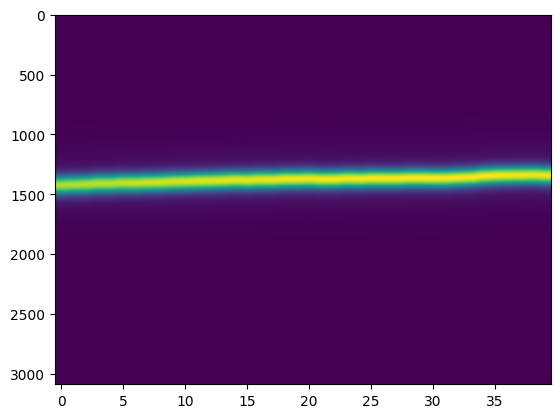

In [110]:
plt.imshow(causticx,aspect='auto')
plt.show()

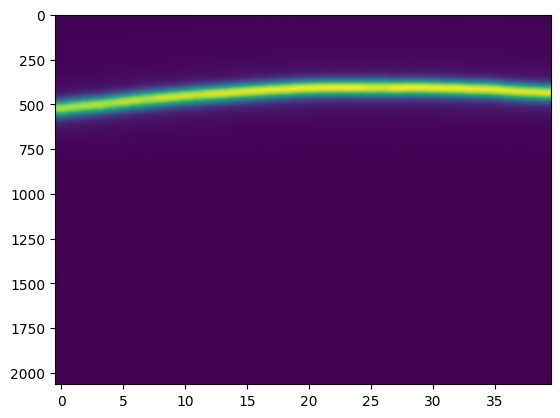

In [111]:
plt.imshow(causticy,aspect='auto')
plt.show()

In [112]:
fwhmsx = [fwhm(causticx[:,i]) for i in range(causticx.shape[1])]
fwhmsy = [fwhm(causticy[:,i]) for i in range(causticy.shape[1])]

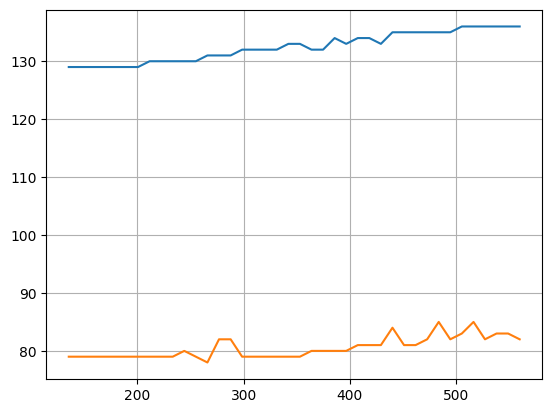

In [113]:
plt.plot(zposes, fwhmsx, label='x')
plt.plot(zposes, fwhmsy, label='y')
plt.grid()
# plt.legend()
plt.show()

In [38]:
fwhmsx

[136,
 135,
 135,
 136,
 135,
 135,
 134,
 134,
 134,
 133,
 132,
 132,
 132,
 132,
 132,
 131,
 131,
 129,
 129,
 129,
 129,
 129]